*Nombre de Grupo*: Perception Roll Failed

*Integrantes*: Maximiliano Fisz, Santiago Rocca

# **Tarea 2: Categorizador de Ambientes usando Bag of Words**


Como vieron en la clase anterior, podemos utilizar el algoritmo de Bag of Words para encontrar similitudes entre el contenido de distintas imagenes detectando si contienen puntos claves semejantes. Esto nos permite hablar de forma mas abstracta sobre nuestras imagenes, concentrandonos en su escena mas que en su forma, es decir, el vocabulario creado por Bag of Word nos brinda un lenguaje comun para hablar de escenas que una computadora puede entender.

Para esta Tarea tendran que utilizar el algoritmo de Bag of Words para clasificar 5 escenas distintas. Las escenas constaran de los siguientes paisajes:

🏜️ **Desierto** | 🌲 **Bosque** | 🧊 **Glaciar** | ⛰️ **Montaña** | 🏖 **Costa**

Luego de crear un clasificador, deberan analizar los siguientes aspectos de su implementacion:

- Comprender el impacto de diferentes parámetros en el rendimiento
- Analizar qué características visuales son más discriminativas
- Evaluar las limitaciones del método en casos reales

## **Dataset Proporcionado**

Para crear su corpus de features se les proporcionará un dataset balanceado con:
- **$≈$600 imágenes por categoría** (3433 total)
- **Train:** $≈$500 imágenes por categoría (2913 total)
- **Test:** $≈$100 imágenes por categoría (520 total)

El DataSet puede encontrarse en Drive por el siguiente Link: [DATASET](https://drive.google.com/drive/folders/1PlpoATt1zt_Q21v3x08tIWA5NZ-EDpAI?usp=sharing)

El cual es un subset curado de un DataSet de Kaggle con 12K imagenes: [DATASET COMPLETO](https://www.kaggle.com/datasets/utkarshsaxenadn/landscape-recognition-image-dataset-12k-images)

## **Implementacion**

### ***Set Up***

In [5]:
!pip3 install -U scikit-learn

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.io import imread
from skimage.feature import SIFT
from skimage.transform import resize

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import time
import glob
import os
from tqdm.notebook import tqdm
import warnings
import math
import random

warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


### ***UTIL***

In [7]:
def indicesDeCategoriaEnLista(etiquetas, categoria):
  """Devuelve los indices donde la etiqueta sea igual que la categoria"""
  return [j for j, etiq in enumerate(etiquetas) if etiq == categoria]

def indexadoIndirecto(idx, lista_indices, lista_principal):
  """Devuelve el resultado de indexar indirectamente una lista"""
  return lista_principal[lista_indices[idx]]

### ***1. Carga y Exploración del Dataset***

**Uso del Drive**

Al tratarse de un dataset con tantos elementos, recomendamos utilizar el dataset directamente desde drive en vez de cargarlo cada vez que quieran trabajar con el. Intenten que todos los participantes del grupo lo tengan en el misma direccion para hacer mas fluido su trabajo.

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
def pathDeArchivoPorCategoria(data_path, categoria):
  """
  Devuelve la direccion de todos las imagenes en la carpeta de la categoria

  Returns:
    archivos: una lista con cada una de las direcciones de archivos.
  """

  categoria_path = os.path.join(data_path, categoria)

  archivos = glob.glob(os.path.join(categoria_path, "*.jpg")) + \
             glob.glob(os.path.join(categoria_path, "*.jpeg")) + \
             glob.glob(os.path.join(categoria_path, "*.png"))

  return archivos

def cargarImagenPorArchivo(archivo):
  """
  Devuelve la imagen cargada en blanco y negro, habiendo sido reescalada si fuera necesario.

  Returns:
    img: La imgen cargada por Archivo.
  """

  img = imread(archivo, as_gray=True)

  # Redimensionar si es necesario (opcional)
  if img.shape[0] > 400 or img.shape[1] > 400:
    img = resize(img, (300, 300), anti_aliasing=True)

  return img

In [10]:
def cargarDataSet(data_path, categorias):
  """
  Carga todas las imágenes del dataset organizadas por categoría

  Returns:
    imagenes: lista de imágenes en escala de grises
    etiquetas: lista de etiquetas correspondientes
    nombres_archivo: lista con nombres de archivos para referencia
  """

  imagenes = []
  etiquetas = []
  nombres_archivo = []

  print(f"Cargando dataset desde: {data_path}")

  # Cargamos las imagenes de cada Categoria
  for categoria in categorias:

    archivos = pathDeArchivoPorCategoria(data_path, categoria)

    print(f"  {categoria}: {len(archivos)} imágenes")

    for archivo in tqdm(archivos, desc=f"Cargando {categoria}"):

      try:
        img = cargarImagenPorArchivo(archivo)
        imagenes.append(img)
        etiquetas.append(categoria)
        nombres_archivo.append(os.path.basename(archivo))

      except Exception as e:
        print(f"Error cargando {archivo}: {e}")

  return imagenes, etiquetas, nombres_archivo


***CARGA***

In [11]:
# Definir categorías de ambientes
CATEGORIAS = ['Desert', 'Forest', 'Glacier', 'Mountain', 'Coast']
COLORES_CATEGORIAS = ['#D4A574', '#228B22', '#87CEEB', '#696969', '#87CEEB']

# Paths del dataset
DATA_PATH = "/content/drive/MyDrive/DataSet/"
TRAIN_PATH = os.path.join(DATA_PATH, "Training BOW")
TEST_PATH = os.path.join(DATA_PATH, "Testing BOW")

# Cargar datasets de entrenamiento y prueba
print("=" * 50)
print("CARGANDO DATASET DE ENTRENAMIENTO")
print("=" * 50)
imagenes_train, etiquetas_train, nombres_train = cargarDataSet(TRAIN_PATH, CATEGORIAS)

print("\n" + "=" * 50)
print("CARGANDO DATASET DE PRUEBA")
print("=" * 50)
imagenes_test, etiquetas_test, nombres_test = cargarDataSet(TEST_PATH, CATEGORIAS)

print(f"\n📊 RESUMEN DEL DATASET:")
print(f"Training: {len(imagenes_train)} imágenes")
print(f"Testing: {len(imagenes_test)} imágenes")
print(f"Total: {len(imagenes_train) + len(imagenes_test)} imágenes")

CARGANDO DATASET DE ENTRENAMIENTO
Cargando dataset desde: /content/drive/MyDrive/DataSet/Training BOW
  Desert: 639 imágenes


Cargando Desert:   0%|          | 0/639 [00:00<?, ?it/s]

  Forest: 651 imágenes


Cargando Forest:   0%|          | 0/651 [00:00<?, ?it/s]

  Glacier: 500 imágenes


...

  Mountain: 100 imágenes


Cargando Mountain:   0%|          | 0/100 [00:00<?, ?it/s]

  Coast: 100 imágenes


Cargando Coast:   0%|          | 0/100 [00:00<?, ?it/s]


📊 RESUMEN DEL DATASET:
Training: 2913 imágenes
Testing: 520 imágenes
Total: 3433 imágenes


***VISUALIZACION***

In [12]:
# Visualización de ejemplos del dataset
def mostrarEjemplosDataSet(imagenes, etiquetas, categorias, n_ejemplos=2):
  """Muestra ejemplos de cada categoría del dataset"""

  fig, axes = plt.subplots(len(categorias), n_ejemplos, figsize=(15, 12))
  fig.suptitle('Ejemplos del Dataset por Categoría', fontsize=16, fontweight='bold')

  for i, categoria in enumerate(categorias):
    # Encontrar índices de esta categoría
    indices_categoria = indicesDeCategoriaEnLista(etiquetas, categoria)
    random.shuffle(indices_categoria)

    # Mostramos imagenes de Ejemplos por categoria
    for j in range(n_ejemplos):

        img = indexadoIndirecto(j, indices_categoria, imagenes)
        axes[i, j].imshow(img, cmap='gray', clim=(0,1))
        axes[i, j].set_title(f'{categoria}', fontweight='bold')
        axes[i, j].axis('off')

  plt.tight_layout()
  plt.show()

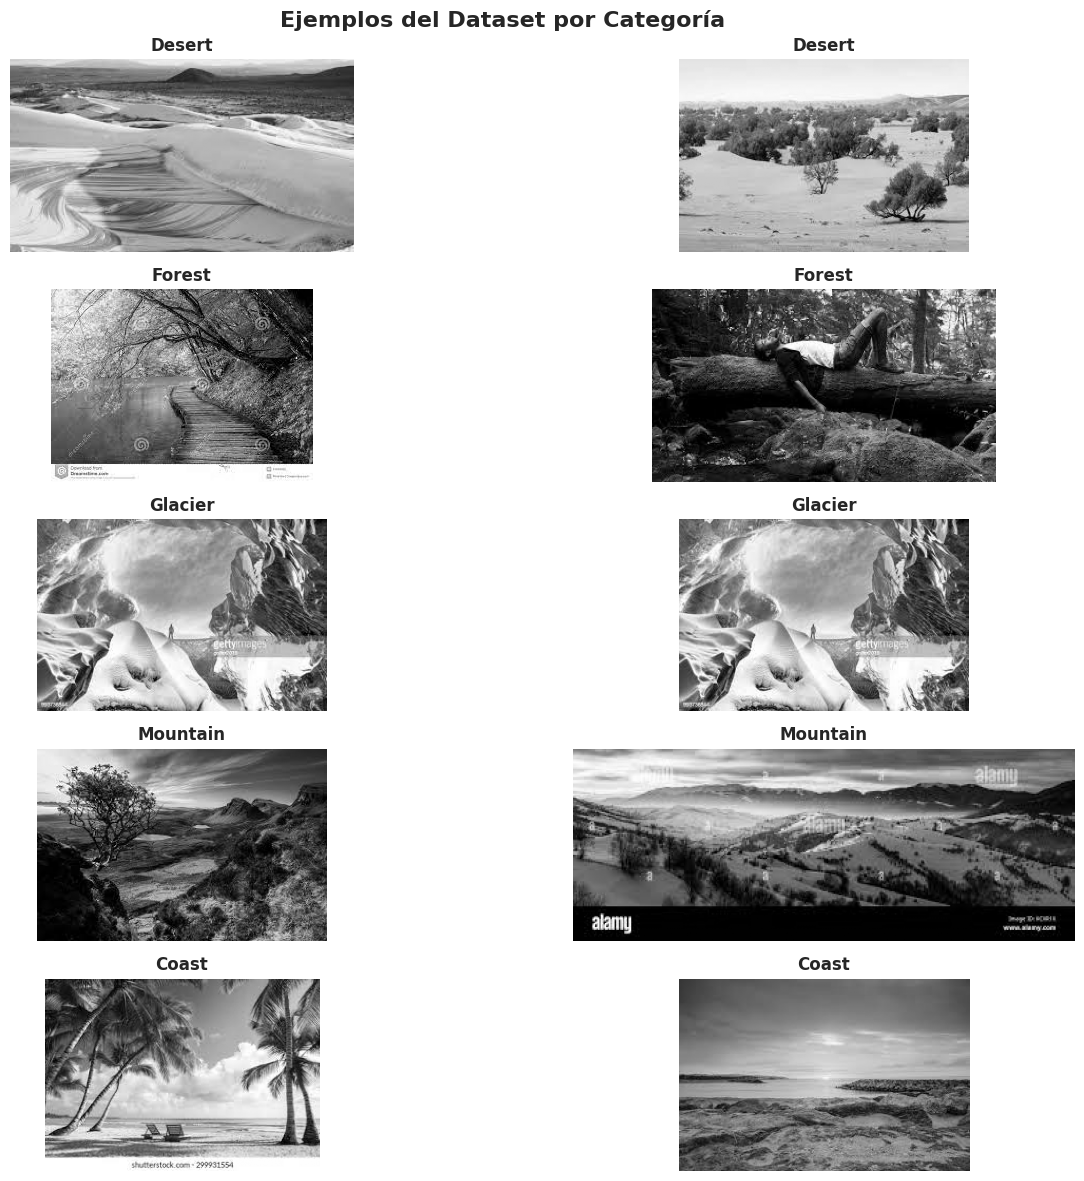

In [13]:
mostrarEjemplosDataSet(imagenes_test, etiquetas_test, CATEGORIAS)

### ***2. Extracción de Características SIFT***
Con las imagenes cargadas, empezaremos por extraer cada uno de sus keypoints y descriptores de SIFT correspondientes. Luego utilizaremos estos datos para crear nuestras palabras visuales.

In [14]:
def extraerSIFTImagen(imagen):
  """
  Extrae características SIFT de una imagen

  Returns:
    keypoints: coordenadas de los puntos clave
    descriptores: descriptores SIFT (128 dimensiones cada uno)
  """
  sift = SIFT()
  sift.detect_and_extract(imagen)

  return sift.keypoints, sift.descriptors

In [15]:

def extraerSIFTDataSet(imagenes, etiquetas):
  """
  Extrae SIFT de todo el dataset

  Returns:
    keypoints_dataset: lista de keypoints por imagen
    descriptores_dataset: lista de descriptores por imagen
    estadisticas: diccionario con estadísticas de extracción
  """

  keypoints_dataset = []
  descriptores_dataset = []

  # Estadísticas por categoría
  stats = {cat: {'total_keypoints': 0, 'num_images': 0} for cat in CATEGORIAS}

  print("Extrayendo características SIFT...")

  # i: indice | img: imagen correspondiente | etiqueta: etiqueta correspondiente
  for i, (img, etiqueta) in enumerate(tqdm(zip(imagenes, etiquetas), total=len(imagenes))):

    keypoints, descriptores = extraerSIFTImagen(img)

    keypoints_dataset.append(keypoints)
    descriptores_dataset.append(descriptores)

    # Actualizar estadísticas
    stats[etiqueta]['total_keypoints'] += len(keypoints)
    stats[etiqueta]['num_images'] += 1

  # Calcular promedios
  for categoria in stats:
    if stats[categoria]['num_images'] > 0:
      stats[categoria]['promedio_keypoints'] = stats[categoria]['total_keypoints'] / stats[categoria]['num_images']

  return keypoints_dataset, descriptores_dataset, stats

In [16]:
# Extraer SIFT del dataset de entrenamiento
print("\n" + "=" * 50)
print("EXTRACCIÓN DE CARACTERÍSTICAS SIFT - TRAINING")
print("=" * 50)

keypoints_train, descriptores_train, stats_train = extraerSIFTDataSet(imagenes_train, etiquetas_train)

# Mostrar estadísticas
print("\n📊 ESTADÍSTICAS DE EXTRACCIÓN SIFT:")
for categoria in CATEGORIAS:
    total = stats_train[categoria]['total_keypoints']
    promedio = stats_train[categoria]['promedio_keypoints']
    print(f"{categoria}: {total} keypoints total, {promedio:.1f} promedio por imagen")



EXTRACCIÓN DE CARACTERÍSTICAS SIFT - TRAINING
Extrayendo características SIFT...


  0%|          | 0/2913 [00:00<?, ?it/s]


📊 ESTADÍSTICAS DE EXTRACCIÓN SIFT:
Desert: 123189 keypoints total, 192.8 promedio por imagen
Forest: 411384 keypoints total, 631.9 promedio por imagen
Glacier: 223074 keypoints total, 446.1 promedio por imagen
Mountain: 188035 keypoints total, 376.1 promedio por imagen
Coast: 228616 keypoints total, 367.0 promedio por imagen


***VISUALIZACION***


VISUALIZACIÓN DE KEYPOINTS


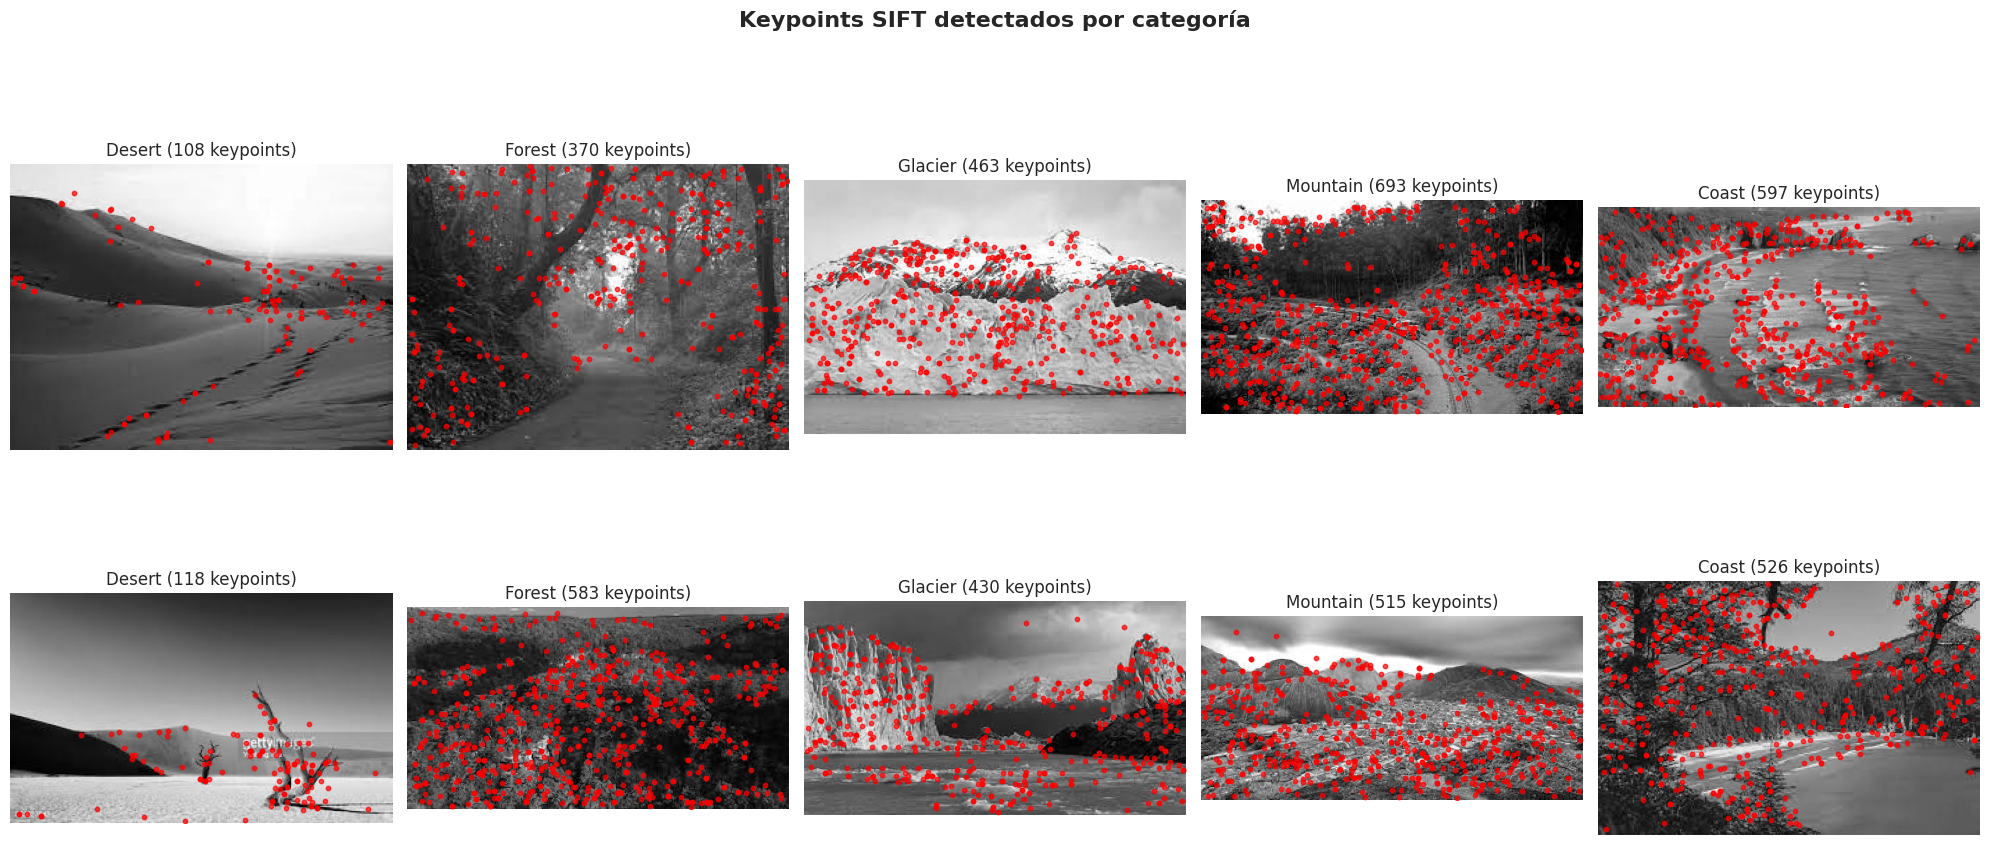

In [ ]:
# Visualizar keypoints en ejemplos
def mostrar_keypoints_ejemplos(imagenes, keypoints, etiquetas, categorias):
  """Muestra keypoints detectados en ejemplos de cada categoría"""

  fig, axes = plt.subplots(2, len(categorias), figsize=(20, 10))
  fig.suptitle('Keypoints SIFT detectados por categoría', fontsize=16, fontweight='bold')

  for i, categoria in enumerate(categorias):
    indices_categoria = indicesDeCategoriaEnLista(etiquetas, categoria)
    random.shuffle(indices_categoria)

    for row in range(2):
      img = indexadoIndirecto(row, indices_categoria, imagenes)
      kp = indexadoIndirecto(row, indices_categoria, keypoints)

      # Imagen original
      axes[row, i].imshow(img, cmap='gray')

      # Keypoints
      axes[row, i].scatter(kp[:, 1], kp[:, 0], s=10, c='red', alpha=0.7)

      axes[row, i].set_title(f'{categoria} ({len(kp)} keypoints)')
      axes[row, i].axis('off')

  plt.tight_layout()
  plt.show()

print("\n" + "=" * 50)
print("VISUALIZACIÓN DE KEYPOINTS")
print("=" * 50)
mostrar_keypoints_ejemplos(imagenes_train, keypoints_train, etiquetas_train, CATEGORIAS)

### ***3. Cross Validation***

Para poder encontrar los mejores parametros a usar en el categorizador sin caer en la trampa de **sobreajustarse a los datos de test**, utilizaremos la tecnica de **Cross Validation**.

Dividiremos nuestro set de entrenamiento en 5 subsets balanceados en categoria y aleatorios. Por cada uno de los subsets, tomaremos el resto de los 4 para **entrenar un categorizador** utilizando los meta-parametros a testear (numero de clusters, batch size, etc) y los testearemos sobre el subset apartado.

Por ultimo, utilizaremos la combinacion de meta-parametros que mejor accuracy hayan conseguido en **promedio**.

Con esta tecnica aumentamos las chances de generalizar sin tener que aumentar los datos de entrenamiento, ya que estariamos eligiendo los parametros que mayor capacidad de generalizacion obtuvieron.

In [17]:
def getPorcionDeSubset(lista, indices_cat, cat_subset_inicio, cat_subset_fin):
  """
    Devuelve una sublista del arreglo original siendo indexada indirectamente
    por un arreglo con los indices de una categoria en especifico
  """

  return [indexadoIndirecto(idx, indices_cat, lista) for idx in range(cat_subset_inicio, cat_subset_fin)]

def crearSubsets(imagenes, etiquetas, nombres, keypoints, descriptores, n_subsets=5):
  """Devuelve una lista con los subsets creados al dividir el dataset de entrenamiento original"""

  # Encontramos los indices que le pertenecen a cada categoria
  # Encontramos cuantos item de cada categoria deberia haber por subset
  indices_categorias = {cat: indicesDeCategoriaEnLista(etiquetas,cat) for cat in CATEGORIAS}
  categoria_por_subset = {cat: math.ceil(len(indices_categorias[cat]) / n_subsets) for cat in CATEGORIAS}

  # Reordenamos los indices de las categorias de forma aleatoria
  for cat in CATEGORIAS:
    random.shuffle(indices_categorias[cat])

  subsets = []

  for subset_index in range(n_subsets):
    subset = {
        'imagenes': [],
        'etiquetas': [],
        'nombres': [],
        'keypoints': [],
        'descriptores': [],
        'stats': {cat: {'num_images': 0} for cat in CATEGORIAS}
      }

    for cat in CATEGORIAS:

      cat_indices = indices_categorias[cat]
      cat_subset_inicio = subset_index * categoria_por_subset[cat]
      cat_subset_fin = min(cat_subset_inicio + categoria_por_subset[cat], len(indices_categorias[cat]))

      cat_etiquetas = getPorcionDeSubset(etiquetas, cat_indices, cat_subset_inicio, cat_subset_fin)
      cat_descriptores = getPorcionDeSubset(descriptores, cat_indices, cat_subset_inicio, cat_subset_fin)
      cat_nombres = getPorcionDeSubset(nombres, cat_indices, cat_subset_inicio, cat_subset_fin)
      cat_imagenes = getPorcionDeSubset(imagenes, cat_indices, cat_subset_inicio, cat_subset_fin)
      cat_keypoints = getPorcionDeSubset(keypoints, cat_indices, cat_subset_inicio, cat_subset_fin)

      subset['etiquetas'] += (cat_etiquetas)
      subset['nombres'] += (cat_nombres)
      subset['descriptores']+=(cat_descriptores)
      subset['imagenes']+=(cat_imagenes)
      subset['keypoints']+=(cat_keypoints)

      subset['stats'][cat]['num_images'] = len(cat_imagenes)

    subsets.append(subset)

  return subsets

In [36]:
subsets = crearSubsets(imagenes_train, etiquetas_train, nombres_train, keypoints_train, descriptores_train)

for i in range(len(subsets)):
    subset = subsets[i]

    print(f"Subset {i}")
    print(f"Imagenes Totales: {len(subset['etiquetas'])}")

    for categoria in CATEGORIAS:
      print(f"\t{categoria}: {subset['stats'][categoria]['num_images']} imagenes")

    print("\n")

Subset 0
Imagenes Totales: 584
	Desert: 128 imagenes
	Forest: 131 imagenes
	Glacier: 100 imagenes
	Mountain: 100 imagenes
	Coast: 125 imagenes


Subset 1
Imagenes Totales: 584
	Desert: 128 imagenes
	Forest: 131 imagenes
	Glacier: 100 imagenes
	Mountain: 100 imagenes
	Coast: 125 imagenes


Subset 2
Imagenes Totales: 584
	Desert: 128 imagenes
	Forest: 131 imagenes
	Glacier: 100 imagenes
	Mountain: 100 imagenes
	Coast: 125 imagenes


Subset 3
Imagenes Totales: 584
	Desert: 128 imagenes
	Forest: 131 imagenes
	Glacier: 100 imagenes
	Mountain: 100 imagenes
	Coast: 125 imagenes


Subset 4
Imagenes Totales: 577
	Desert: 127 imagenes
	Forest: 127 imagenes
	Glacier: 100 imagenes
	Mountain: 100 imagenes
	Coast: 123 imagenes




In [ ]:
def imagenesDeEjemploSubSet(subset, n_ejemplos=4):
  """Muestra ejemplos de cada categoría del subset"""

  fig, axes = plt.subplots(len(CATEGORIAS), n_ejemplos, figsize=(15, 12))
  fig.suptitle('Ejemplos del Sub Dataset por Categoría', fontsize=16, fontweight='bold')

  for i, categoria in enumerate(CATEGORIAS):
    # Encontrar índices de esta categoría
    indices_categoria = indicesDeCategoriaEnLista(subset['etiquetas'], categoria)
    random.shuffle(indices_categoria)

    # Mostramos imagenes de Ejemplos por categoria
    for j in range(n_ejemplos):

        img = indexadoIndirecto(j, indices_categoria, subset['imagenes'])
        axes[i, j].imshow(img, cmap='gray', clim=(0,1))
        axes[i, j].set_title(f'{categoria}', fontweight='bold')
        axes[i, j].axis('off')

  plt.tight_layout()
  plt.show()

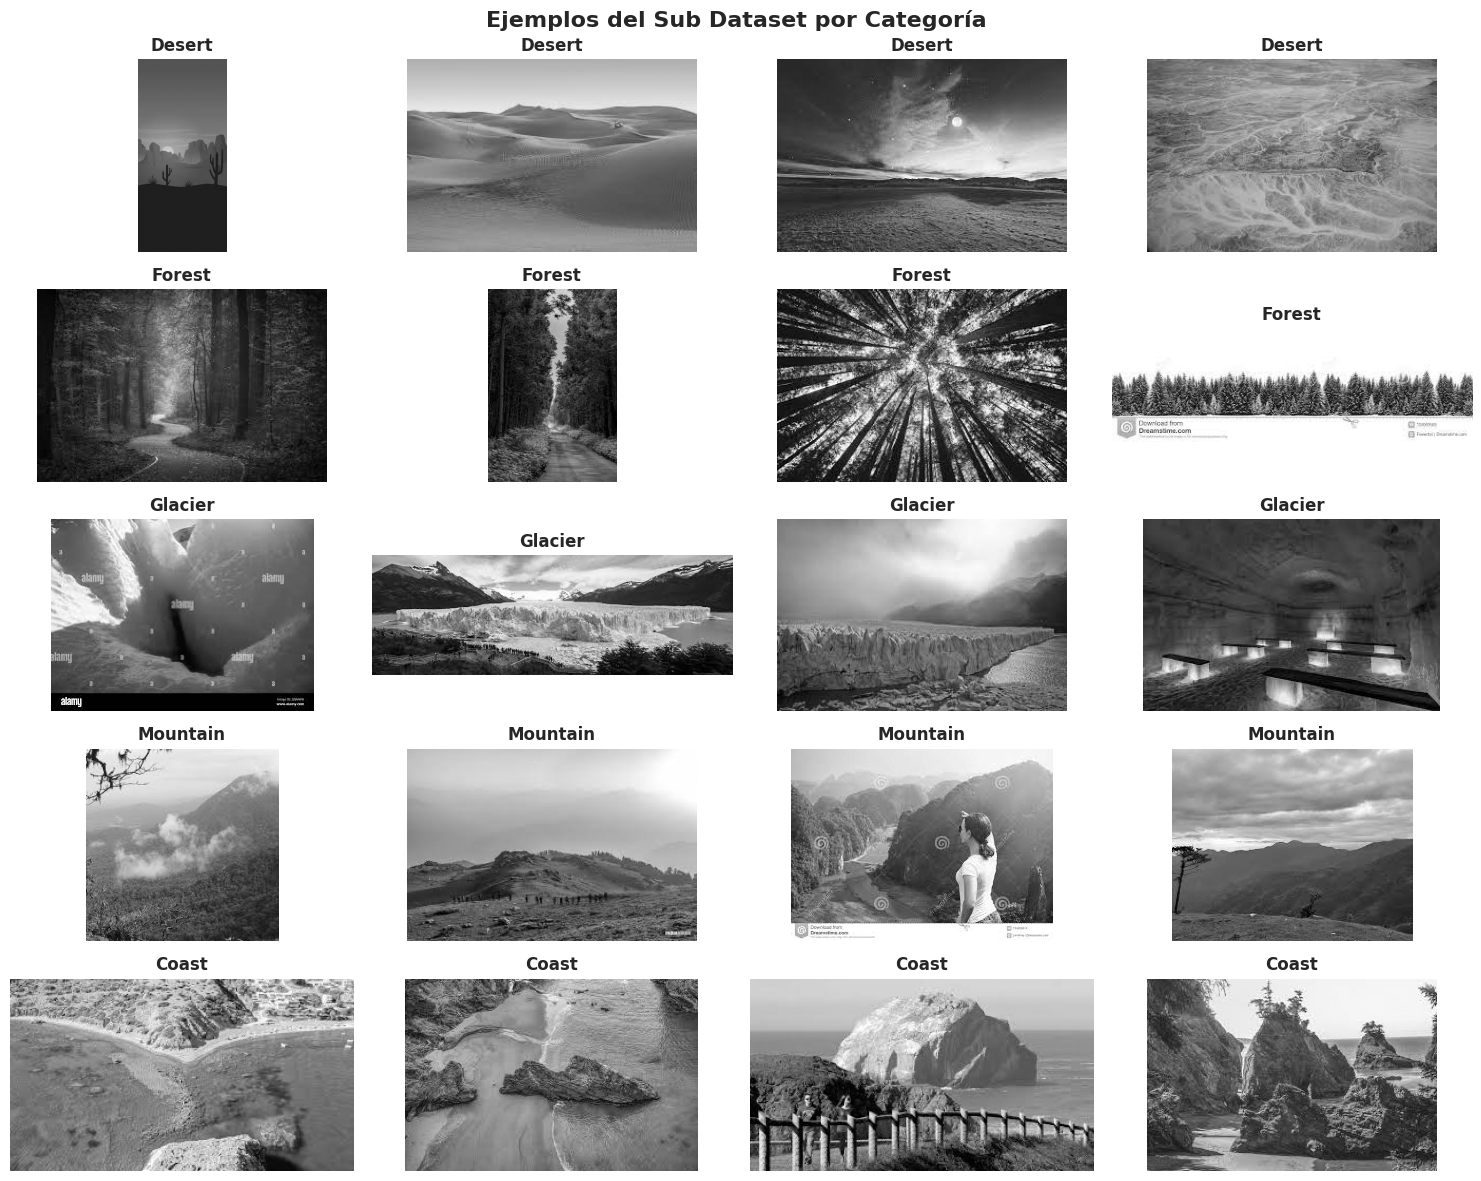

In [ ]:
imagenesDeEjemploSubSet(subsets[0])

In [18]:
def unirSubsets(subsets):
  """Devuelve un subset conformado por la union de los subset en la lista"""

  subset_union = {
        'imagenes': [],
        'etiquetas': [],
        'nombres': [],
        'keypoints': [],
        'descriptores': [],
        'stats': {cat: {'num_images': 0} for cat in CATEGORIAS}
      }

  for subset in subsets:

    subset_union['etiquetas'] += subset['etiquetas']
    subset_union['nombres']+= subset['nombres']
    subset_union['descriptores']+= subset['descriptores']
    subset_union['imagenes']+= subset['imagenes']
    subset_union['keypoints']+= subset['keypoints']

    for cat in CATEGORIAS:
      subset_union['stats'][cat]['num_images'] += len(subset['etiquetas'])

  return subset_union


Por fines demostrativos, por ahora usaremos un dataset de entrenamiento fijo creado por [`subset_0`, `subset_1`, `subset_2`, `subset_3`] y `subset_4` sera el conjunto de validacion. Para encontrar los mejores parametros tendran que realizar el mismo procedimiento con cada uno de los subsets.

In [ ]:
training_subset = unirSubsets([subsets[0], subsets[1], subsets[2], subsets[3]])
validation_subset = subsets[4]

print(f"Training Subset")
print(f"Imagenes Totales: {len(training_subset['etiquetas'])}")

for categoria in CATEGORIAS:
  print(f"\t{categoria}: {training_subset['stats'][categoria]['num_images']} imagenes")

print("\n")

Training Subset
Imagenes Totales: 2336
	Desert: 2336 imagenes
	Forest: 2336 imagenes
	Glacier: 2336 imagenes
	Mountain: 2336 imagenes
	Coast: 2336 imagenes




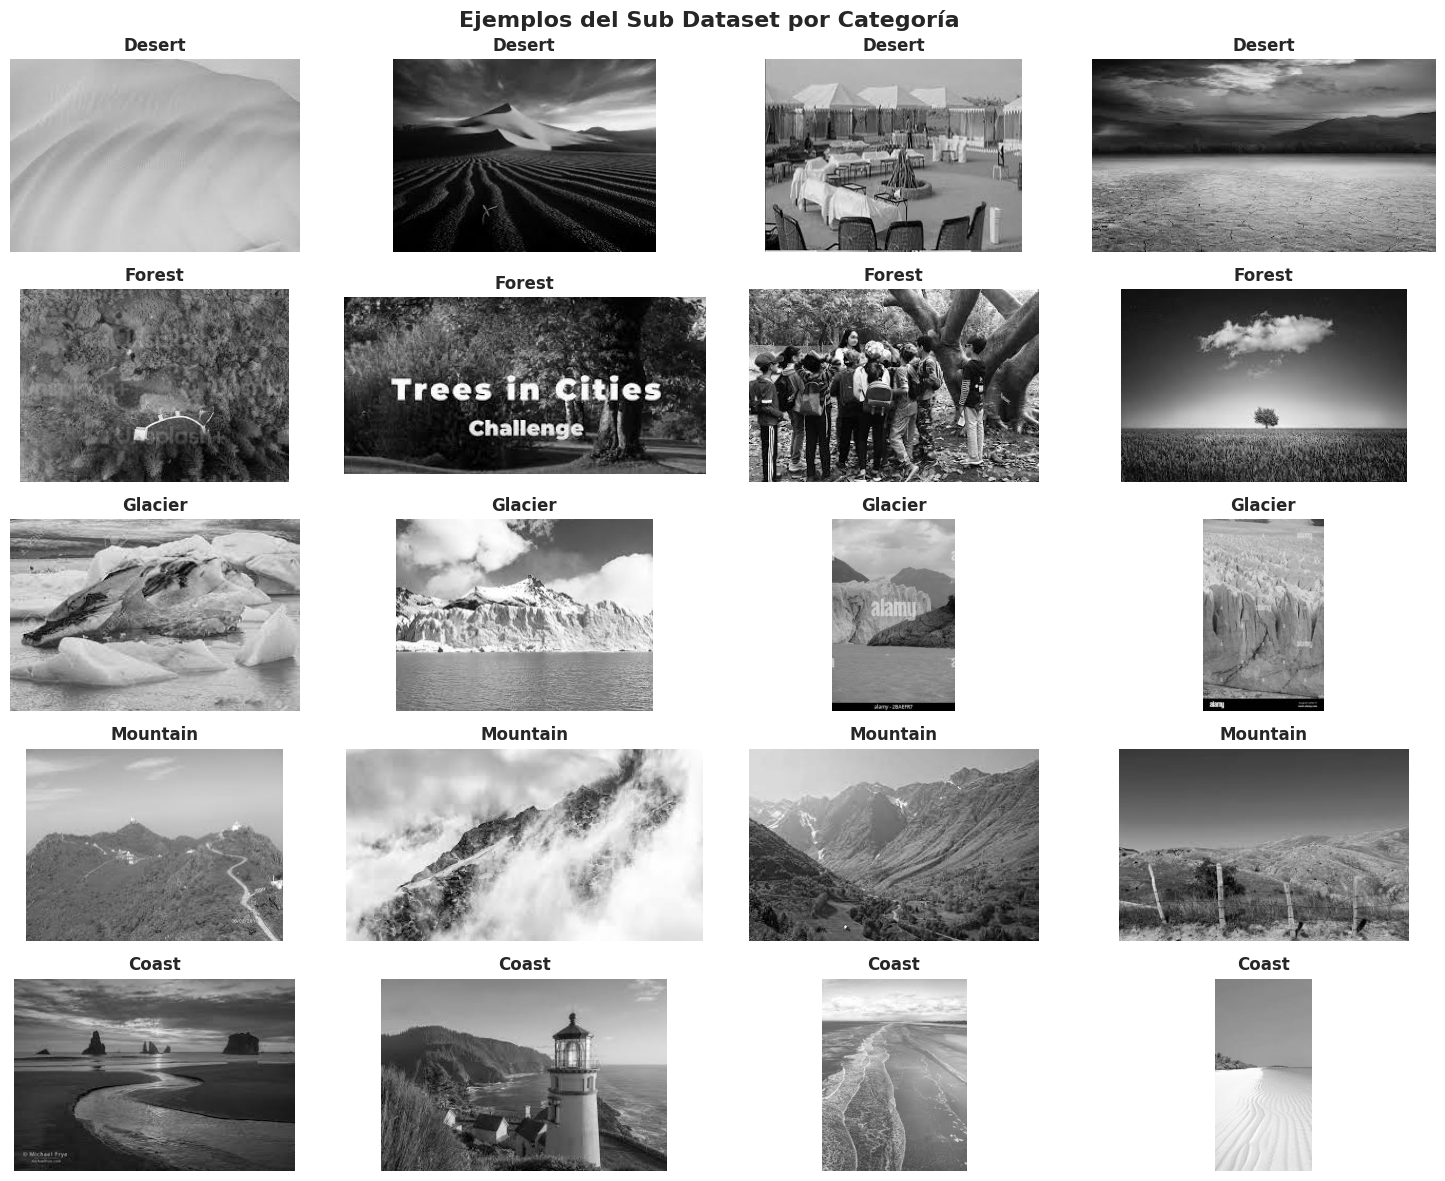

In [ ]:
imagenesDeEjemploSubSet(training_subset)

### ***PIPELINE de Entrenamiento***

Usaremos un `k` y `batch_size` fijo para ejemplificar, pero ustedes deberan parametrizar el pipeline de entrenamiento para poder encontrar los mejores paramentros utilizando **croos-validation**

---

*Construccion de Vocabulario Visual* ➡️ *Representacion BOW* ➡️ *Procesamiento de la Representacion* ➡️ *Entrenamiento de Categorizador* ➡️ *Validacion*

### ***4. Creación del Vocabulario Visual***

Ya teniendo los descriptores, podemos clasificarlos para comprender que keypoints eran similares a traves de las imagenes y empezar a hablar sobre el contenido de ellas.

Para esto utilizaremos un categorizador llamado MiniBatchKMeans, el cual hace lo mismo que K-means, pero en vez de tomar en cuenta todos los puntos, solo toma una cantidad fija de puntos aleatorios. El algoritmo eligira puntos de forma aleatoria iterativamente y devolvera los clusters encontrados que cuasaron la minima cantidad de varianza intra-cluster (menor distancia con el centroide).

Para mas informacion pueden leer la documentacion [oficial](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html) y su [comparacion con kmeans](https://scikit-learn.org/stable/modules/clustering.html#mini-batch-kmeans)

---

***Construccion de Vocabulario Visual*** ➡️ *Representacion BOW* ➡️ *Procesamiento de la Representacion* ➡️ *Entrenamiento de Categorizador* ➡️ *Validacion*

In [19]:
# Crear matriz global de descriptores para clustering
def crearMatrizDescriptores(descriptores_dataset):
    """
    Combina todos los descriptores en una matriz global para K-means
    Donde cada fila es un descriptor
    """
    matriz_descriptores = []

    # COMPLETAR...
    # AGREGAR CADA DESCRIPTOR A matriz_descriptores
    for descriptores in descriptores_dataset:
      for descriptor in descriptores:
        matriz_descriptores.append(descriptor)

    return np.array(matriz_descriptores, dtype=np.float64)

In [20]:
def construirVocabulario(descriptores, k=200, batch_size=1024, random_state=42):
  """
  Construye vocabulario visual usando K-means

  Args:
    descriptores: matriz de descriptores
    k: número de clusters (palabras visuales)
    batch_size: Cantidad de keypoints aleatorios que utilizara para encontrar los clusters (chico para hacer pruebas, luego incrementar)
    random_state: semilla para reproducibilidad

  Returns:
    kmeans: Categorizador K-Means entrenado para categorizar los descriptores a su centroido mas cercano
  """
  print(f"Construyendo vocabulario con k={k} palabras visuales...")

  kmeans = MiniBatchKMeans(
      n_clusters=k,
      random_state=random_state,
      batch_size=batch_size,
      max_iter=300,
      n_init=5,
      verbose=0
      )

  kmeans.fit(descriptores)

  return kmeans

In [ ]:
print("\n" + "=" * 50)
print("CONSTRUCCIÓN DEL VOCABULARIO VISUAL")
print("=" * 50)

K = 200
# training_subset tiene varias cosas, las imagenes originales, sus descriptores, sus keyports, las etiquetas, etc. Uno para cada imagen, el len de descriptores es el len del traning_subset
matriz_descriptores = crearMatrizDescriptores(training_subset['descriptores'])

print(f"\n--- Probando k = {K} ---")

# Creamos el vocabulario y tomamos su tiempo de creacion
inicio = time.time()
vocabulario = construirVocabulario(matriz_descriptores, K)
fin = time.time()
tiempo = fin - inicio

print(f"✅ Vocabulario creado en {tiempo:.1f} segundos")
print(f"    Varianza intra-cluster: {vocabulario.inertia_:.4f}") # Cuanto mas chico, mas concentrados seran los clusters


CONSTRUCCIÓN DEL VOCABULARIO VISUAL

--- Probando k = 200 ---
Construyendo vocabulario con k=200 palabras visuales...
✅ Vocabulario creado en 17.9 segundos
    Varianza intra-cluster: 71123005393.4060


### ***5. Representación Bag of Words***
Ya teniendo nuestro corpus o palabras visuales, podremos empezar a re-describir nuestras imagenes segun este. Gracias a esto podemos "hablar" de todas nuestras imagenes en el mismo "lenguaje", el nuevo descriptor.

Para la descripcion de una imagen utilizaremos la frecuencia de cada palabra en el vocabulario.

---

*Construccion de Vocabulario Visual* ➡️ ***Representacion BOW*** ➡️ *Procesamiento de la Representacion* ➡️ *Entrenamiento de Categorizador* ➡️ *Validacion*

In [21]:
from scipy.cluster.vq import vq

def descriptoresABOW(descriptores_imagen, vocabulario):
    """
    Convierte descriptores de una imagen a representación BoW

    Args:
        descriptores_imagen: np.array de descriptores SIFT de una imagen
        vocabulario: objeto MiniBatchKMeans entrenado (modelo del vocabulario visual)

    Returns:
        histograma: vector de frecuencias de palabras visuales (BoW)
    """
    n_clusters = vocabulario.n_clusters

    # Asignar cada descriptor al centroide más cercano (palabra visual)
    asignaciones = vq(descriptores_imagen, vocabulario.cluster_centers_)

    # Construir histograma de frecuencias de palabras visuales
    histograma, _ = np.histogram(asignaciones, bins=n_clusters, range=(0,n_clusters-1), density=None, weights=None)

    return histograma.astype(float)

In [22]:
def crearMatrizBOW(descriptores_dataset, vocabulario):
    """
    Crea matriz BoW para todo el dataset
    Donde Cada fila es la frecuencia del vocabulario en una imagen
    """
    matriz_bow = []

    print("Creando representaciones BoW...")

    # Tomamos los descriptores de cada imagen
    # Encontramos la frecuencia de cada palabra en el vocabulario (descriptor Bag Of Word)
    # Agregamos la nueva representacion en la matriz
    # COMPLETAR...

    for descriptor in descriptores_dataset:
      frecuenciaDePalabra = descriptoresABOW(descriptor, vocabulario)
      matriz_bow.append(frecuenciaDePalabra)

    return np.array(matriz_bow)

In [ ]:
print("\n" + "=" * 50)
print("CONSTRUCCIÓN DE REPRESENTACIONES BAG OF WORDS")
print("=" * 50)

print(f"\n--- Creando BoW con k={K} ---")
representaciones_bow = crearMatrizBOW(training_subset['descriptores'], vocabulario)
print(f"✅ Matriz BoW shape: {representaciones_bow.shape}")



CONSTRUCCIÓN DE REPRESENTACIONES BAG OF WORDS


NameError: name 'K' is not defined

### ***6. TF-IDF***
Con la Matriz de Representacion de Bag Of Words creada, podemos empezar a transformarla para intentar conseguir un mejor puntaje de forma barata. Una de nuestras opciones es aplicarle **TF-IDF**, presentado en la clase practica, con la intencion de darle mas importancia a las palabras visuales menos frecuentes y bajar el impacto de palabras comunes que no aportan informacion. Si pensamos en una analogia con texto, seria el equivalente de "bajarle el precio" a conectores, pronombres, articulos y etc.

$$
\text{Tf-idf}_{t,d} = \text{tf}_{t,d} ⋅ log(\frac{N}{\text{df}_t})
$$

donde
- $\text{Tf-idf}_{t,d}$ sera el nuevo valor de la palabra $t$ para la imagen $d$
- $\text{tf}_{t,d}$ era la frecuencia de la palabra $t$ para la imagen $d$
- $N$ es la cantidad de imagenes totales
- $\text{df}_t$ es la cantidad de imagenes en la que la palabra $t$ aparece al menos una vez.

---

*Construccion de Vocabulario Visual* ➡️ *Representacion BOW* ➡️ ***Procesamiento de la Representacion*** ➡️ *Entrenamiento de Categorizador* ➡️ *Validacion*

In [23]:
def aplicar_tfidf(matriz_bow):
  """
  Aplica transformación TF-IDF a matriz de frecuencias

  Args:
    matriz_bow: matriz de frecuencias (n_images x n_words)

  Returns:
    matriz_tfidf: matriz con pesos TF-IDF
  """

  matriz_tfidf = matriz_bow.copy()
  N = len(matriz_bow)

  for imagen in matriz_tfidf:
    for frecuencia in range(0, matriz_bow.shape[1]):
      dft = 0
      for i in matriz_tfidf:
        if i[frecuencia] > 0:
          dft += 1
      imagen[frecuencia] = imagen[frecuencia] * np.log(N / dft)

  #COMPLETAR (Ser cuidadoso en no modificar la matriz original)

  return matriz_tfidf

In [24]:
def aplicar_tfidf_manual(bow):
    bow = bow.copy().astype(float)
    N, V = bow.shape

    # Document frequency for each term
    df = np.count_nonzero(bow > 0, axis=0)

    # Avoid division by zero (in case some word never appears)
    df[df == 0] = 1

    # Compute IDF vector
    idf = np.log(N / df)

    # Multiply TF by IDF
    bow *= idf

    return bow

In [ ]:
print("\n" + "=" * 50)
print("TF-IDF")
print("=" * 50)

# Aplicamos TF-IDF
print(f"\n--- Aplicando TF-IDF con k={K} ---")

representaciones_tfidf = aplicar_tfidf_manual(representaciones_bow)

# Comparar estadísticas antes y después
bow_mean = np.mean(representaciones_bow)
tfidf_mean = np.mean(representaciones_tfidf)

print(f"Frecuencias simples - Media: {bow_mean:.4f}")
print(f"TF-IDF - Media: {tfidf_mean:.4f}")


TF-IDF

--- Aplicando TF-IDF con k=200 ---
Frecuencias simples - Media: 2.1532
TF-IDF - Media: 0.7454


### ***7. Entrenamiento de un Clasificador***

Ya habiendo aplicado todo el **post-procesamiento** que quisieramos a nuestra aplicacion, solo nos queda usarla para entrenar un **Categorizador de Escenas** que luego utilizaremos para hacer predicciones con imagenes entrantes nuevas.

En este caso usaremos una **SVC** por su flexibilidad y por ya haber sido presentada en la Tarea anterior. Recordemos que una **SVC** encuentra los mejores Hiper Planos para separar los puntos de cada categoria, dejandonos aplicarle una **transformacion a los datos de entradas a un espacio de dimensionalidad mayor** si nos es necesario para encontrar hiperplanos validos.

---

*Construccion de Vocabulario Visual* ➡️ *Representacion BOW* ➡️ *Procesamiento de la Representacion* ➡️ ***Entrenamiento de Categorizador*** ➡️ *Validacion*

In [25]:
def entrenar_svm(descriptores_train, etiquetas_train):
    """
    Entrena un clasificador SVM

    Returns:
        clf: pipeline con SVC
    """

    # make_pipeline les permite crear un pipeline sobre el propio categorizador SVC
    # por si quieren hacer un procesamiento mas general de los datos antes de enviarlos a la SVC
    clf = make_pipeline(SVC(kernel='linear', probability=True))
    clf.fit(descriptores_train, etiquetas_train)
    return clf

In [ ]:
print(f"\n{'='*50}")
print(f"ENTRENANDO CLASIFICADOR CON K={K}")
print(f"{'='*50}")

# Clasificadores SVM
# Por cada procesamiento que hagan sobre la representacion, deberan crear un nuevo categorizador
# entrenado sobre ellos.

clasificador_bow = entrenar_svm(representaciones_bow, training_subset['etiquetas'])

print(f"\n✅ Clasificador BoW Entrenado")

clasificador_tfidf = entrenar_svm(representaciones_tfidf, training_subset['etiquetas'])

print(f"\n✅ Clasificador TFIDF Entrenado")



ENTRENANDO CLASIFICADOR CON K=200

✅ Clasificador BoW Entrenado

✅ Clasificador TFIDF Entrenado


### ***8. Validacion***

Con nuestro Clasificador entrenado, solo queda probarlo con los datos de validacion. Para esto tendremos que representar nuestras imagenes de validacion utilizando el vocabulario y las transformaciones de post-procesamiento con las que se entreno la SVM.

Luego podremos analizar con mas detalles que puntos debiles tiene nuestro clasificador, por ejemplo, cuales son las categorias que mas se confunde entre si.

---

*Construccion de Vocabulario Visual* ➡️ *Representacion BOW* ➡️ *Procesamiento de la Representacion* ➡️ *Entrenamiento de Categorizador* ➡️ ***Validacion***

In [26]:
def evaluar_clasificador_svm(clasificador, descriptores_bow_test, etiquetas_test, nombre_experimento=""):
  """
  Evalúa el clasificador SVM
  Args:
    clasificador: Clasificador a Evaluar
    descriptores_bow_test: Descriptores de BoW a categorizar
    etiquetas_test: Ground Truth para cada descriptor
    nombre_experimento: Nombre opcional a imprimr

  Returns:
    predicciones: Etiquetas predichas por el clasificador para cada muestra del conjunto de prueba.
    confianzas: Probabilidad más alta asignada por el modelo a la clase predicha para cada muestra (valor entre 0 y 1).
    accuracy: Proporción de etiquetas correctamente clasificadas sobre el total de muestras: (n° aciertos) / (n° total).
    precision: Para cada categoría, proporción de verdaderos positivos entre todos los predichos como esa categoría: TP / (TP + FP).
    recall: Para cada categoría, proporción de verdaderos positivos entre los casos reales de esa categoría: TP / (TP + FN).
    f1: Para cada categoría, media armónica entre precisión y recall: 2 * (precision * recall) / (precision + recall).
    support: Número real de muestras en cada categoría dentro del conjunto de prueba (distribución real por clase).
    confusion_matrix: Matriz de Confusion
  """

  print(f"Evaluando clasificador: {nombre_experimento}")

  # Predicción
  predicciones = clasificador.predict(descriptores_bow_test)

  # Confianzas: tomamos la probabilidad de la clase predicha
  confianzas_prob = clasificador.predict_proba(descriptores_bow_test)
  confianzas = confianzas_prob.max(axis=1)

  # Métricas
  accuracy = accuracy_score(etiquetas_test, predicciones)

  precision, recall, f1, support = precision_recall_fscore_support(
      etiquetas_test, predicciones, average=None, labels=CATEGORIAS
  )

  # Creamos una Matriz de Confusion para ver en que categorias se confunde nuestro clasificador
  cm = confusion_matrix(etiquetas_test, predicciones, labels=CATEGORIAS)

  return {
    'predicciones': predicciones,
    'confianzas': confianzas,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'support': support,
    'confusion_matrix': cm
  }

In [ ]:
print(f"\n{'='*50}")
print(f"VALIDACION CON K={K}")
print(f"{'='*50}")
print()

# Creamos las Representaciones de BoW con el vocabulario obtenido para los datos de validacion

bow_validacion = crearMatrizBOW(validation_subset['descriptores'], vocabulario)
tfidf_validacion = aplicar_tfidf(crearMatrizBOW(validation_subset['descriptores'], vocabulario))

etiquetas_validacion = validation_subset['etiquetas']

# Validamos cada Categorizador
resultado_bow = evaluar_clasificador_svm(clasificador_bow, bow_validacion, etiquetas_validacion, f"SVM-BoW (k={K})")
resultado_tfidf = evaluar_clasificador_svm(clasificador_tfidf, tfidf_validacion, etiquetas_validacion, f"SVM-TF-IDF (k={K})")

resultados_experimentos = {
  'bow': resultado_bow,
  'tfidf': resultado_tfidf
}

# Deberia darle Aprox un 0.5
print(f"\nRESULTADOS k={K}:")
print(f"\tBoW Accuracy: {resultado_bow['accuracy']:.3f}")
print(f"\tTF-IDF Accuracy: {resultado_tfidf['accuracy']:.3f}")



VALIDACION CON K=200

Creando representaciones BoW...
Creando representaciones BoW...
Evaluando clasificador: SVM-BoW (k=200)
Evaluando clasificador: SVM-TF-IDF (k=200)

RESULTADOS k=200:
	BoW Accuracy: 0.516
	TF-IDF Accuracy: 0.506


### ***8 Bis. Analisis de Resultados***
Ya teniendo una muestra de como funciona nuestro categorizador, analizemos en mas detalle su desempeño.

#### **Funciones de Analisis**

In [27]:
def crearTablaResultados(resultados, k, metodos):
  """Crea tabla resumen con todos los resultados"""

  print("\n📊 TABLA RESUMEN DE RESULTADOS")
  print("=" * 90)
  print(f"{'Config':<35} {'Accuracy':<10} {'Precisión':<12} {'Recall':<10} {'F1-Score':<10}")

  for (metodo, titulo) in metodos:
    res = resultados[metodo]
    config = f"{titulo} (k={k})"
    acc = res['accuracy']
    prec = np.mean(res['precision'])
    rec = np.mean(res['recall'])
    f1 = np.mean(res['f1'])

    print(f"{config:<35} {acc:<10.3f} {prec:<12.3f} {rec:<10.3f} {f1:<10.3f}")

  print("-" * 90)
  print()

In [28]:
def plotConfusionMatrices(resultados, k_valor, metodos):
    """Plotea matrices de confusión para un valor de k específico"""

    fig, axes = plt.subplots(1, len(metodos), figsize=(15, 6))

    if len(metodos) == 1:
      axes = [axes]

    for i, (metodo, titulo) in enumerate(metodos):

        cm = resultados[metodo]['confusion_matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=[cat for cat in CATEGORIAS],
                   yticklabels=[cat for cat in CATEGORIAS],
                   ax=axes[i])

        axes[i].set_title(f'{titulo} (k={k_valor})')
        axes[i].set_xlabel('Predicción')
        axes[i].set_ylabel('Verdadero')

    plt.tight_layout()
    plt.show()

In [29]:
def analizar_errores(resultados, metodo, testing_set):
  """Devuelve los errores de clasificación"""

  resultado = resultados[metodo]
  predicciones = resultado['predicciones']

  etiquetas = testing_set['etiquetas']
  imagenes = testing_set['imagenes']
  nombres = testing_set['nombres']

  # Encontrar errores
  errores = []
  for i, (real, pred) in enumerate(zip(etiquetas, predicciones)):
    if real != pred:
      errores.append({
        'real': real,
        'predicho': pred,
        'imagen': imagenes[i],
        'imagen_nombre': nombres[i],
        'confianza': resultado['confianzas'][i]
      })

  return errores

In [30]:
def imprimirErrores(errores, k, metodo, total):
  """Imprime informacion sobre los errores"""

  print(f"\n🔍 ANÁLISIS DE ERRORES ({metodo.upper()}, k={k})")
  print("-" * 50)
  print(f"Total de errores: {len(errores)} de {total} imágenes")
  print(f"Accuracy: {(total - len(errores))/total:.3f}")

  # Análisis de confusiones más comunes
  confusiones = {}
  for error in errores:
    par = (error['real'], error['predicho'])
    if par not in confusiones:
      confusiones[par] = []
    confusiones[par].append(error)

  print(f"\n📊 CONFUSIONES MÁS COMUNES:")
  for (real, pred), casos in sorted(confusiones.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"  {real} → {pred}: {len(casos)} casos")

  print()

In [31]:
# Mostrar ejemplos de errores
def mostrarEjemplosErrores(errores, n_ejemplos=4):
  """Muestra ejemplos visuales de errores de clasificación"""

  if len(errores) == 0:
    print("¡No hay errores para mostrar!")
    return

  n_mostrar = min(n_ejemplos, len(errores))
  errores_sample = random.sample(errores, k=n_mostrar)
  fig, axes = plt.subplots(n_mostrar, 1, figsize=(15, 10))

  fig.suptitle('Ejemplos de Errores de Clasificación', fontsize=16, fontweight='bold')

  for i in range(n_mostrar):
    error = errores_sample[i]

    axes[i].imshow(error['imagen'], cmap='gray', clim=(0,1))

    axes[i].set_title(f'Real: {error["real"].title()}\n'
                      f'Predicho: {error["predicho"].title()}\n'
                      f'Confianza: {error["confianza"]:.3f}')

    axes[i].axis('off')

  plt.tight_layout()
  plt.show()

#### **Analisis**

In [ ]:
print("\n" + "=" * 50)
print("ANÁLISIS DE RESULTADOS 1/2")
print("=" * 50)

# Tabla resumen de resultados
metodos = [('bow', 'Frecuencias Simples'), ('tfidf', 'TF-IDF')]

crearTablaResultados(resultados_experimentos, K, metodos)
plotConfusionMatrices(resultados_experimentos, K, metodos)

In [32]:
print("\n" + "=" * 50)
print("ANÁLISIS DE RESULTADOS 2/2")
print("=" * 50)

# Encontramos los errores de nuestro categorizador
errores = analizar_errores(resultados_experimentos, 'bow', validation_subset)

# Imprimimos la informacion relevante
imprimirErrores(errores, K, 'bow', len(validation_subset['etiquetas']))


ANÁLISIS DE RESULTADOS 2/2


NameError: name 'resultados_experimentos' is not defined

In [ ]:
# Mostramos algunos ejemplos de errores
mostrarEjemplosErrores(errores)

---
## **CONSIGNAS**




### 🧪 Parte 1: **Cross Validation**

Luego de completar el codigo faltante, realicen un experimento de cross validation probando combinaciones de los siguientes hiperparámetros:

  - Número de clusters para BoW (`k`):

    `100`, `200`, `400`, `800`

  - Tamaño de batch para entrenamiento del vocabulario (`batch_size`):

    `512`, `1024`, `2048`, `4096`, `8192`

Para cada combinación, registren:

  - **Precisión** (accuracy)

  - **Tiempo de entrenamiento**

Para completar esta parte, sera necesario que automaticen el pipeline visto en las celdas anteriores.

### 📊 Parte 2: **Análisis de Resultados**

Respondan las siguientes preguntas a partir de los resultados obtenidos:

1.   ¿Cómo afecta el valor de `k` al rendimiento del clasificador? Expliquen el impacto en precisión y en el costo computacional (tiempo y memoria).

2.   ¿Qué relación observan entre `batch_size` y el tiempo de cómputo o el rendimiento del modelo? ¿Existe un valor de `batch_size` que parezca óptimo?

3.   ¿Cuál consideran que es la mejor combinación de `k` y `batch_size`? Justifiquen y argumente el criterio utilizado: ¿priorizaron precisión, eficiencia, o un balance entre ambos?




### 🔄 Parte 3: Procesamiento (TF-IDF)

1. ¿Mejora el rendimiento al utilizar una representación con TF-IDF en lugar de frecuencias simples?

  - Comparen la precisión obtenida con la versión sin TF-IDF.


### 🤖 Parte 4: Resultados Finales y Conclusiones

Una vez analizados los hiperparámetros y modelos, seleccionen la mejor configuración del sistema:

- Valor óptimo de `k`
- Valor óptimo de `batch_size`
- Tipo de representación final: **BoW**, **BoW + TF-IDF**

Entrenen un modelo definitivo utilizando **todo el conjunto de entrenamiento** con estos parámetros y evalúelo sobre el **conjunto de test**.

---

### 📈 1. Métricas Finales

- Reporten las métricas obtenidas en el conjunto de test:
  - `accuracy`
  - `precision`
  - `recall`
  - `f1-score` (por clase)
- Incluya la **matriz de confusión** correspondiente.

---

### 🔍 2. Análisis de Errores

- ¿Qué categorías o ambientes se confunden más entre sí?
- ¿Por qué creen que ocurre esa confusión?
  - Ejemplos: similitud visual, baja representación de datos, condiciones de iluminación.

---

### 🧠 3. Ejemplos Específicos

Muestren al menos **2 o 3 ejemplos concretos** donde el sistema se equivoca:

- Etiqueta verdadera vs. predicción
- Comentario sobre el posible motivo del error

---

### 📊 4. Visualizaciones

Escriban visualizaciones que ayuden a interpretar el comportamiento del sistema:

- **Distribución de palabras visuales por categoría**
- **Keypoints más característicos** por clase

---

### ⚠️ 5. Limitaciones Observadas

Describan **2 o 3 limitaciones** del sistema:

- ¿En qué tipos de imágenes o ambientes tiende a fallar?
- ¿Qué factores afectan negativamente el rendimiento?

---

### 🚀 6. Propuestas de Mejora

Propongan al menos **2 o 3 ideas concretas** para mejorar el sistema. Por ejemplo:

- Inclusión de color o textura como información adicional
- Cambiar el clasificador (Random Forest, redes neuronales)
- Limpieza del dataset
- etc

---

## **Respuestas**



### ***Codigo***
Escriban todo el codigo que necesiten aca

In [33]:
# Parte 1: Cross validation

k_values = [100, 200, 400, 800]
batch_size_values = [512, 1024, 2048, 4096, 8192]

results = []

matriz_descriptores = crearMatrizDescriptores(training_subset['descriptores'])

for k in k_values:
  for batch_size in batch_size_values:
    print(f"\n{'='*50}")
    print(f"ENTRENANDO CLASIFICADOR CON K={k} Y BATCH_SIZE={batch_size}")
    print(f"{'='*50}")

    times = []

    # Creamos vocabulario

    inicioVoc = time.time()
    vocabulario = construirVocabulario(matriz_descriptores, k, batch_size)
    finVoc = time.time()
    tiempoCreacionVoc = finVoc - inicioVoc
    times.append(("Tiempo de creacion de vocabulario", tiempoCreacionVoc))

    print(f"✅ Vocabulario creado en {tiempoCreacionVoc:.1f} segundos")
    print(f"    Varianza intra-cluster: {vocabulario.inertia_:.4f}")

    # Creamos las dos representaciones

    representaciones_bow = crearMatrizBOW(training_subset['descriptores'], vocabulario)
    representaciones_tfidf = aplicar_tfidf_manual(representaciones_bow)

    # Entrenamos BOW

    inicioTrainBow = time.time()
    clasificador_bow = entrenar_svm(representaciones_bow, training_subset['etiquetas'])
    finTrainBow = time.time()
    tiempoTrainBow = finTrainBow - inicioTrainBow
    times.append(("Tiempo de entrenamiento bow", tiempoTrainBow))
    print(f"✅ Bow entrenado en {tiempoTrainBow:.1f} segundos")

    # Entrenamos Bow+TFIDF

    inicioTrainTFIDF = time.time()
    clasificador_tfidf = entrenar_svm(representaciones_tfidf, training_subset['etiquetas'])
    finTrainTFIDF = time.time()
    tiempoTrainTFIDF = finTrainTFIDF - inicioTrainTFIDF
    times.append(("Tiempo de entrenamiento tfidf", tiempoTrainTFIDF))
    print(f"✅ Bow+TFIDF entrenado en {tiempoTrainTFIDF:.1f} segundos")


    # Creamos las representaciones de validacion el mismo vocabulario, para evaluar

    bow_validacion = crearMatrizBOW(validation_subset['descriptores'], vocabulario)
    tfidf_validacion = aplicar_tfidf(crearMatrizBOW(validation_subset['descriptores'], vocabulario))
    etiquetas_validacion = validation_subset['etiquetas']

    # Validamos cada Categorizador
    resultado_bow = evaluar_clasificador_svm(clasificador_bow, bow_validacion, etiquetas_validacion, f"SVM-BoW (k={k}) (batch size={batch_size})")
    resultado_tfidf = evaluar_clasificador_svm(clasificador_tfidf, tfidf_validacion, etiquetas_validacion, f"SVM-TF-IDF (k={k}) (batch size={batch_size})")

    result = {
        'k': k,
        'batch_size': batch_size,
        'bow': resultado_bow,
        'tfidf': resultado_tfidf,
        'times': times
    }

    results.append(result)

    print(f"\tBoW Accuracy: {resultado_bow['accuracy']:.3f}")
    print(f"\tTF-IDF Accuracy: {resultado_tfidf['accuracy']:.3f}")

    print(f"✅ Iteracion exitosa de K={k} y batch size={batch_size}")

NameError: name 'training_subset' is not defined

In [ ]:
import pickle

In [ ]:
# Guardamos los resultados

with open("results.pkl", "wb") as f:
    pickle.dump(results, f)

In [ ]:
#Cargamos los resultados

with open("results.pkl", "rb") as f:
    results = pickle.load(f)

In [ ]:
# Resultados de precision y tiempo de entrenamiento

for result in results:
  print(f"K={result['k']} - batch size={result['batch_size']} - accuracy bow={result['bow']['accuracy']:.3f} - tiempo train bow={result['times'][1][1]:.1f} - accuracy tfidf={result['tfidf']['accuracy']:.3f} - tiempo train tfidf={result['times'][2][1]:.1f}")

K=100 - batch size=512 - accuracy bow=0.539 - tiempo train bow=304.1 - accuracy tfidf=0.556 - tiempo train tfidf=12.2
K=100 - batch size=1024 - accuracy bow=0.549 - tiempo train bow=297.2 - accuracy tfidf=0.548 - tiempo train tfidf=10.0
K=100 - batch size=2048 - accuracy bow=0.555 - tiempo train bow=273.7 - accuracy tfidf=0.558 - tiempo train tfidf=11.1
K=100 - batch size=4096 - accuracy bow=0.536 - tiempo train bow=290.0 - accuracy tfidf=0.527 - tiempo train tfidf=10.2
K=100 - batch size=8192 - accuracy bow=0.532 - tiempo train bow=282.1 - accuracy tfidf=0.546 - tiempo train tfidf=9.5
K=200 - batch size=512 - accuracy bow=0.530 - tiempo train bow=218.9 - accuracy tfidf=0.525 - tiempo train tfidf=19.8
K=200 - batch size=1024 - accuracy bow=0.516 - tiempo train bow=189.3 - accuracy tfidf=0.506 - tiempo train tfidf=24.0
K=200 - batch size=2048 - accuracy bow=0.510 - tiempo train bow=203.1 - accuracy tfidf=0.518 - tiempo train tfidf=22.4
K=200 - batch size=4096 - accuracy bow=0.511 - tiem

In [ ]:
#Copia resultados bloque anterior
# K=100 - batch size=512 - accuracy bow=0.539 - tiempo train bow=304.1 - accuracy tfidf=0.556 - tiempo train tfidf=12.2
# K=100 - batch size=1024 - accuracy bow=0.549 - tiempo train bow=297.2 - accuracy tfidf=0.548 - tiempo train tfidf=10.0
# K=100 - batch size=2048 - accuracy bow=0.555 - tiempo train bow=273.7 - accuracy tfidf=0.558 - tiempo train tfidf=11.1
# K=100 - batch size=4096 - accuracy bow=0.536 - tiempo train bow=290.0 - accuracy tfidf=0.527 - tiempo train tfidf=10.2
# K=100 - batch size=8192 - accuracy bow=0.532 - tiempo train bow=282.1 - accuracy tfidf=0.546 - tiempo train tfidf=9.5
# K=200 - batch size=512 - accuracy bow=0.530 - tiempo train bow=218.9 - accuracy tfidf=0.525 - tiempo train tfidf=19.8
# K=200 - batch size=1024 - accuracy bow=0.516 - tiempo train bow=189.3 - accuracy tfidf=0.506 - tiempo train tfidf=24.0
# K=200 - batch size=2048 - accuracy bow=0.510 - tiempo train bow=203.1 - accuracy tfidf=0.518 - tiempo train tfidf=22.4
# K=200 - batch size=4096 - accuracy bow=0.511 - tiempo train bow=200.7 - accuracy tfidf=0.501 - tiempo train tfidf=20.2
# K=200 - batch size=8192 - accuracy bow=0.475 - tiempo train bow=209.0 - accuracy tfidf=0.484 - tiempo train tfidf=21.8
# K=400 - batch size=512 - accuracy bow=0.438 - tiempo train bow=25.4 - accuracy tfidf=0.473 - tiempo train tfidf=12.6
# K=400 - batch size=1024 - accuracy bow=0.471 - tiempo train bow=21.9 - accuracy tfidf=0.496 - tiempo train tfidf=10.0
# K=400 - batch size=2048 - accuracy bow=0.489 - tiempo train bow=14.0 - accuracy tfidf=0.503 - tiempo train tfidf=10.9
# K=400 - batch size=4096 - accuracy bow=0.484 - tiempo train bow=32.8 - accuracy tfidf=0.473 - tiempo train tfidf=12.0
# K=400 - batch size=8192 - accuracy bow=0.485 - tiempo train bow=22.0 - accuracy tfidf=0.499 - tiempo train tfidf=10.2
# K=800 - batch size=512 - accuracy bow=0.523 - tiempo train bow=10.2 - accuracy tfidf=0.527 - tiempo train tfidf=8.3
# K=800 - batch size=1024 - accuracy bow=0.506 - tiempo train bow=9.8 - accuracy tfidf=0.503 - tiempo train tfidf=8.1
# K=800 - batch size=2048 - accuracy bow=0.499 - tiempo train bow=8.9 - accuracy tfidf=0.516 - tiempo train tfidf=9.4
# K=800 - batch size=4096 - accuracy bow=0.478 - tiempo train bow=10.0 - accuracy tfidf=0.492 - tiempo train tfidf=9.4
# K=800 - batch size=8192 - accuracy bow=0.497 - tiempo train bow=10.1 - accuracy tfidf=0.504 - tiempo train tfidf=9.0

Parte 2: Analisis de resultados.

¿Cómo afecta el valor de k al rendimiento del clasificador? Expliquen el impacto en precisión y en el costo computacional (tiempo y memoria).

- En general, "pocos" K y "muchos" K por igual pueden no ser optimos por under y overfitting respectivamente, uno deberia usar alguna tecnica para encontrar exactamente K que da mejores resultados. Para los K que usamos nosotros, en general mantenemos una precision regular exceptuando con 400, donde perdemos precision en comparacion. En cuanto al costo computacional, deberian crecer ambos al aumentar K, ya que debemos calcular mas centroides, sin embargo, tenemos una tendencia decreciente de la mano del aumento del K, con un salto significativo cuando K es mayor o igual a 400, donde el tiempo de entrenamiento se reduce en 10x. Teoría: encontramos el rango de K perfecto (400 - 800+).

¿Qué relación observan entre batch_size y el tiempo de cómputo o el rendimiento del modelo? ¿Existe un valor de batch_size que parezca óptimo?

- En cuanto al tiempo de entrenamiento, en general batch sizes mas altos tardan mas en entrenar pero en cambio, cuando se compara el rendimiento hay picos, minimos y minimos que dependen del K.

¿Cuál consideran que es la mejor combinación de k y batch_size? Justifiquen y argumente el criterio utilizado: ¿priorizaron precisión, eficiencia, o un balance entre ambos?

- Pareceria que lo mejor que se puede hacer es primero elegir el K. En nuestro caso, elegimos usar K = 800, ya que los tiempos de entrenamiento son muy bajos pero mantienen una precision relativamente buena comparado con las otras opciones. En cuanto al batch size, usaremos 512 pero realisticamente, cualquiera de las opciones seria adecuada, la diferencia es despreciable.


In [ ]:
def calcular_promedios(resultados):
    total_bow = 0.0
    total_tfidf = 0.0
    n = len(resultados)

    for res in resultados:
        total_bow += res['bow']['accuracy']
        total_tfidf += res['tfidf']['accuracy']

    promedio_bow = total_bow / n
    promedio_tfidf = total_tfidf / n

    return promedio_bow, promedio_tfidf

In [ ]:
prom_bow, prom_tfidf = calcular_promedios(results)
print(f"Promedio precisión BOW: {prom_bow:.3f}")
print(f"Promedio precisión TF-IDF: {prom_tfidf:.3f}")

Promedio precisión BOW: 0.506
Promedio precisión TF-IDF: 0.513


In [ ]:
#Copia resultados bloque anterior
#Promedio precisión BOW: 0.506
#Promedio precisión TF-IDF: 0.513

Parte 3: Procesamiento (TF-IDF)
¿Mejora el rendimiento al utilizar una representación con TF-IDF en lugar de frecuencias simples?

Comparen la precisión obtenida con la versión sin TF-IDF.

- En promedio, la precision aumenta al usar la transformada, y ya que la operacion no es particularmente costosa, usaremos esa version para nuestro modelo final.

Parte 4: Resultados finales y conclusiones

Valor óptimo de k: 800

Valor óptimo de batch_size: 512

Tipo de representación final: BoW + TF-IDF

In [37]:
# Creamos el subset de validacion y rehacemos el subset de training pero usando todas las imagenes

keypoints_test, descriptores_test, _ = extraerSIFTDataSet(imagenes_test, etiquetas_test)

subsetsTest = crearSubsets(imagenes_test, etiquetas_test, nombres_test, keypoints_test, descriptores_test)

testing_subset = unirSubsets([subsetsTest[0], subsetsTest[1], subsetsTest[2], subsetsTest[3], subsetsTest[4]])
training_subset = unirSubsets([subsets[0], subsets[1], subsets[2], subsets[3], subsets[4]])

print(f"Training Subset")
print(f"Imagenes Totales: {len(training_subset['etiquetas'])}")

print(f"Testing Subset")
print(f"Imagenes Totales: {len(testing_subset['etiquetas'])}")

Extrayendo características SIFT...


  0%|          | 0/520 [00:00<?, ?it/s]

Training Subset
Imagenes Totales: 2913
Testing Subset
Imagenes Totales: 520


In [38]:
# Parte 4: entrenamiento con parametros ajustados sobre todo el dataset de training

k = 800
batch_size = 512

matriz_descriptores = crearMatrizDescriptores(training_subset['descriptores'])

print(f"\n{'='*50}")
print(f"ENTRENANDO CLASIFICADOR CON K={k} Y BATCH_SIZE={batch_size}")
print(f"{'='*50}")

# Creamos vocabulario
inicioVoc = time.time()
vocabulario = construirVocabulario(matriz_descriptores, k, batch_size)
finVoc = time.time()
tiempoCreacionVoc = finVoc - inicioVoc

print(f"✅ Vocabulario creado en {tiempoCreacionVoc:.1f} segundos")
print(f"    Varianza intra-cluster: {vocabulario.inertia_:.4f}")

# Creamos las dos representaciones

representaciones_bow = crearMatrizBOW(training_subset['descriptores'], vocabulario)
representaciones_tfidf = aplicar_tfidf_manual(representaciones_bow)

# Entrenamos Bow+TFIDF

inicioTrainTFIDF = time.time()
clasificador_tfidf = entrenar_svm(representaciones_tfidf, training_subset['etiquetas'])
finTrainTFIDF = time.time()
tiempoTrainTFIDF = finTrainTFIDF - inicioTrainTFIDF
print(f"✅ Bow+TFIDF entrenado en {tiempoTrainTFIDF:.1f} segundos")


# Creamos las representaciones de validacion el mismo vocabulario, para evaluar

bow_validacion = crearMatrizBOW(testing_subset['descriptores'], vocabulario)
tfidf_validacion = aplicar_tfidf(crearMatrizBOW(testing_subset['descriptores'], vocabulario))
etiquetas_validacion = testing_subset['etiquetas']

# Validamos cada Categorizador
resultado_final = evaluar_clasificador_svm(clasificador_tfidf, tfidf_validacion, etiquetas_validacion, f"SVM-TF-IDF (k={k}) (batch size={batch_size})")

print(f"\tTF-IDF Accuracy: {resultado_final['accuracy']:.3f}")


ENTRENANDO CLASIFICADOR CON K=800 Y BATCH_SIZE=512
Construyendo vocabulario con k=800 palabras visuales...
✅ Vocabulario creado en 39.5 segundos
    Varianza intra-cluster: 78390704844.5912
Creando representaciones BoW...
✅ Bow+TFIDF entrenado en 13.4 segundos
Creando representaciones BoW...
Creando representaciones BoW...
Evaluando clasificador: SVM-TF-IDF (k=800) (batch size=512)
	TF-IDF Accuracy: 0.425


In [ ]:
# Guardamos los resultados

with open("resultado_final.pkl", "wb") as f:
    pickle.dump(resultado_final, f)

In [ ]:
#Cargamos los resultados

with open("resultado_final.pkl", "rb") as f:
    resultado_final = pickle.load(f)

In [ ]:
resultado_formato_analisis = {
        'k': k,
        'batch_size': batch_size,
        'tfidf': resultado_final
}

Metricas Finales:


ANÁLISIS DE RESULTADOS 1/2

📊 TABLA RESUMEN DE RESULTADOS
Config                              Accuracy   Precisión    Recall     F1-Score  
TF-IDF (k=800)                      0.465      0.463        0.473      0.458     
------------------------------------------------------------------------------------------



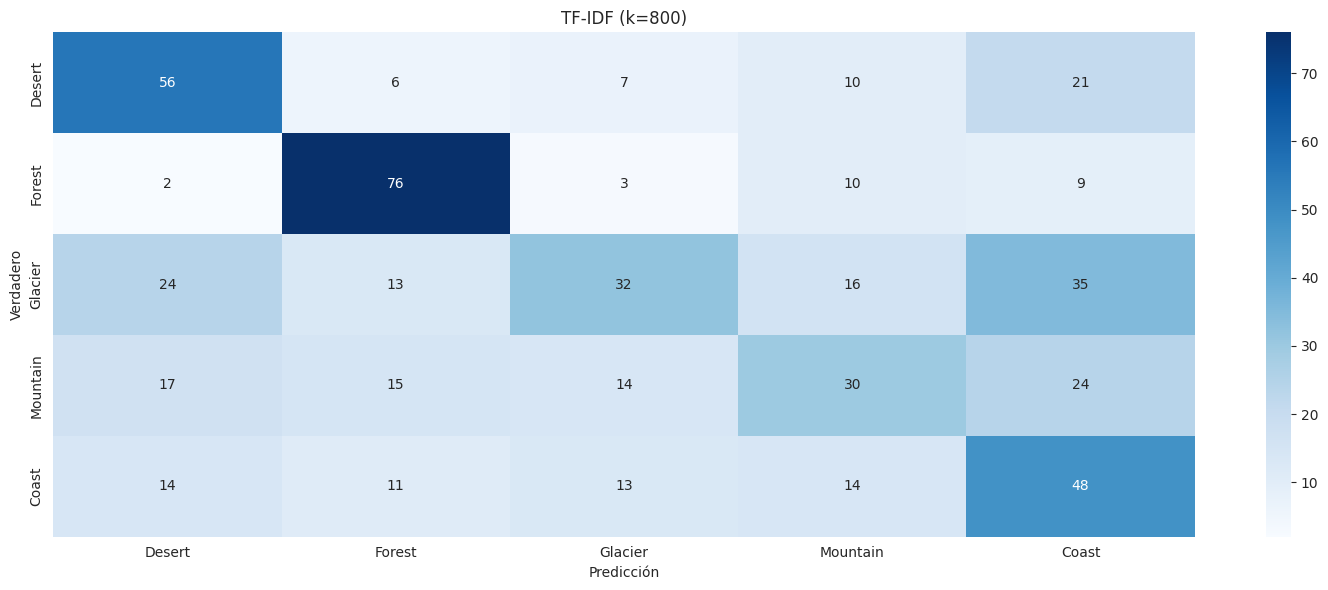

In [ ]:
print("\n" + "=" * 50)
print("ANÁLISIS DE RESULTADOS 1/2")
print("=" * 50)

# Tabla resumen de resultados
metodos = [('tfidf', 'TF-IDF')]

crearTablaResultados(resultado_formato_analisis, k, metodos)
plotConfusionMatrices(resultado_formato_analisis, k, metodos)

Analisis de errores

- La confusion mas tipica es la de clase glaciares siendo confundida con una costa o un desierto (*). Las tres clases son muy similares visualmente para las features que estamos considerando: suelen ser imagenes de paisajes que contienen agua (o arena, que es "igual") y algun tipo de formacion montañosa, sean dunas, glaciares o el bosque/montaña que suele encontrarse tras la costa.

(*) Dos clases que ya de por si, tiene poca accuracy diferenciando ya que sift tiene poca precision diferenciando las suaves dunas del desierto y el calmo mar (ver keypoints encontrados en desiertos y costas).

(*2) La matriz de confusión se encuentra subida con la entrega en el campus para evitar rehacer todo el proceso.


ANÁLISIS DE RESULTADOS 2/2

🔍 ANÁLISIS DE ERRORES (TFIDF, k=800)
--------------------------------------------------
Total de errores: 278 de 520 imágenes
Accuracy: 0.465

📊 CONFUSIONES MÁS COMUNES:
  Glacier → Coast: 35 casos
  Glacier → Desert: 24 casos
  Mountain → Coast: 24 casos
  Desert → Coast: 21 casos
  Mountain → Desert: 17 casos
  Glacier → Mountain: 16 casos
  Mountain → Forest: 15 casos
  Mountain → Glacier: 14 casos
  Coast → Desert: 14 casos
  Coast → Mountain: 14 casos
  Glacier → Forest: 13 casos
  Coast → Glacier: 13 casos
  Coast → Forest: 11 casos
  Desert → Mountain: 10 casos
  Forest → Mountain: 10 casos
  Forest → Coast: 9 casos
  Desert → Glacier: 7 casos
  Desert → Forest: 6 casos
  Forest → Glacier: 3 casos
  Forest → Desert: 2 casos



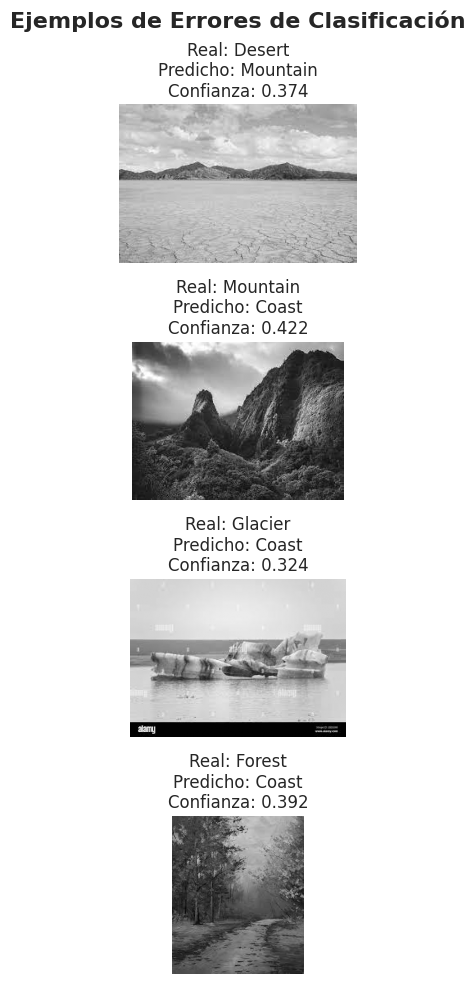

In [ ]:
print("\n" + "=" * 50)
print("ANÁLISIS DE RESULTADOS 2/2")
print("=" * 50)

# Encontramos los errores de nuestro categorizador
errores = analizar_errores(resultado_formato_analisis, 'tfidf', testing_subset)

# Imprimimos la informacion relevante
imprimirErrores(errores, k, 'tfidf', len(testing_subset['etiquetas']))

# Mostramos algunos ejemplos de errores
mostrarEjemplosErrores(errores)

In [ ]:
#Copia resultados bloque anterior
#==================================================
#ANÁLISIS DE RESULTADOS 2/2
#==================================================
#
#🔍 ANÁLISIS DE ERRORES (TFIDF, k=800)
#--------------------------------------------------
#Total de errores: 278 de 520 imágenes
#Accuracy: 0.465
#
#📊 CONFUSIONES MÁS COMUNES:
#  Glacier → Coast: 35 casos
#  Glacier → Desert: 24 casos
#  Mountain → Coast: 24 casos
#  Desert → Coast: 21 casos
#  Mountain → Desert: 17 casos
#  Glacier → Mountain: 16 casos
#  Mountain → Forest: 15 casos
#  Mountain → Glacier: 14 casos
#  Coast → Desert: 14 casos
#  Coast → Mountain: 14 casos
#  Glacier → Forest: 13 casos
#  Coast → Glacier: 13 casos
#  Coast → Forest: 11 casos
#  Desert → Mountain: 10 casos
#  Forest → Mountain: 10 casos
#  Forest → Coast: 9 casos
#  Desert → Glacier: 7 casos
#  Desert → Forest: 6 casos
#  Forest → Glacier: 3 casos
#  Forest → Desert: 2 casos

Ejemplos Especificos

1- Real: Desert. Predicho: Mountain. Tipico caso de una imagen que contiene features presentes en varias de las clases: sectores con arena, un horizonte claramente marcado y montañas. Podría pertenecer a otra clase sin problema.

2- Real: Mountain. Predicho: Coast. Otro ejemplo de lo anterior, muchas imagenes de costas usadas para entrenar son imagenes tomadas desde el agua hacia la costa, con arboles luego de la costa y montañas en el fondo.

3- Real: Glacier. Predicho: Coast. Mismo escenario, aunque hay una feature muy particular del glaciar, predomina el agua y el cielo, tipicos de la costa.

4- Real: Forest. Predicho: Coast. La presencia de arboles dificulta la diferenciacion pero tambien, en particular para este ejemplo, la presencia de un camino en el suelo, que al analizar los keypoints de la imagen entera, no pareceria poder distinguirlo apropiadamente del agua o la arena.


(*) Los ejemplos que usamos estan subidos al campus junto con el resto de la entrega.

Visualizaciones

La distribucion y algun ejemplo de keypoints mas frecuentes en un subset se encuentran en el campus junto con el resto de la entrega.

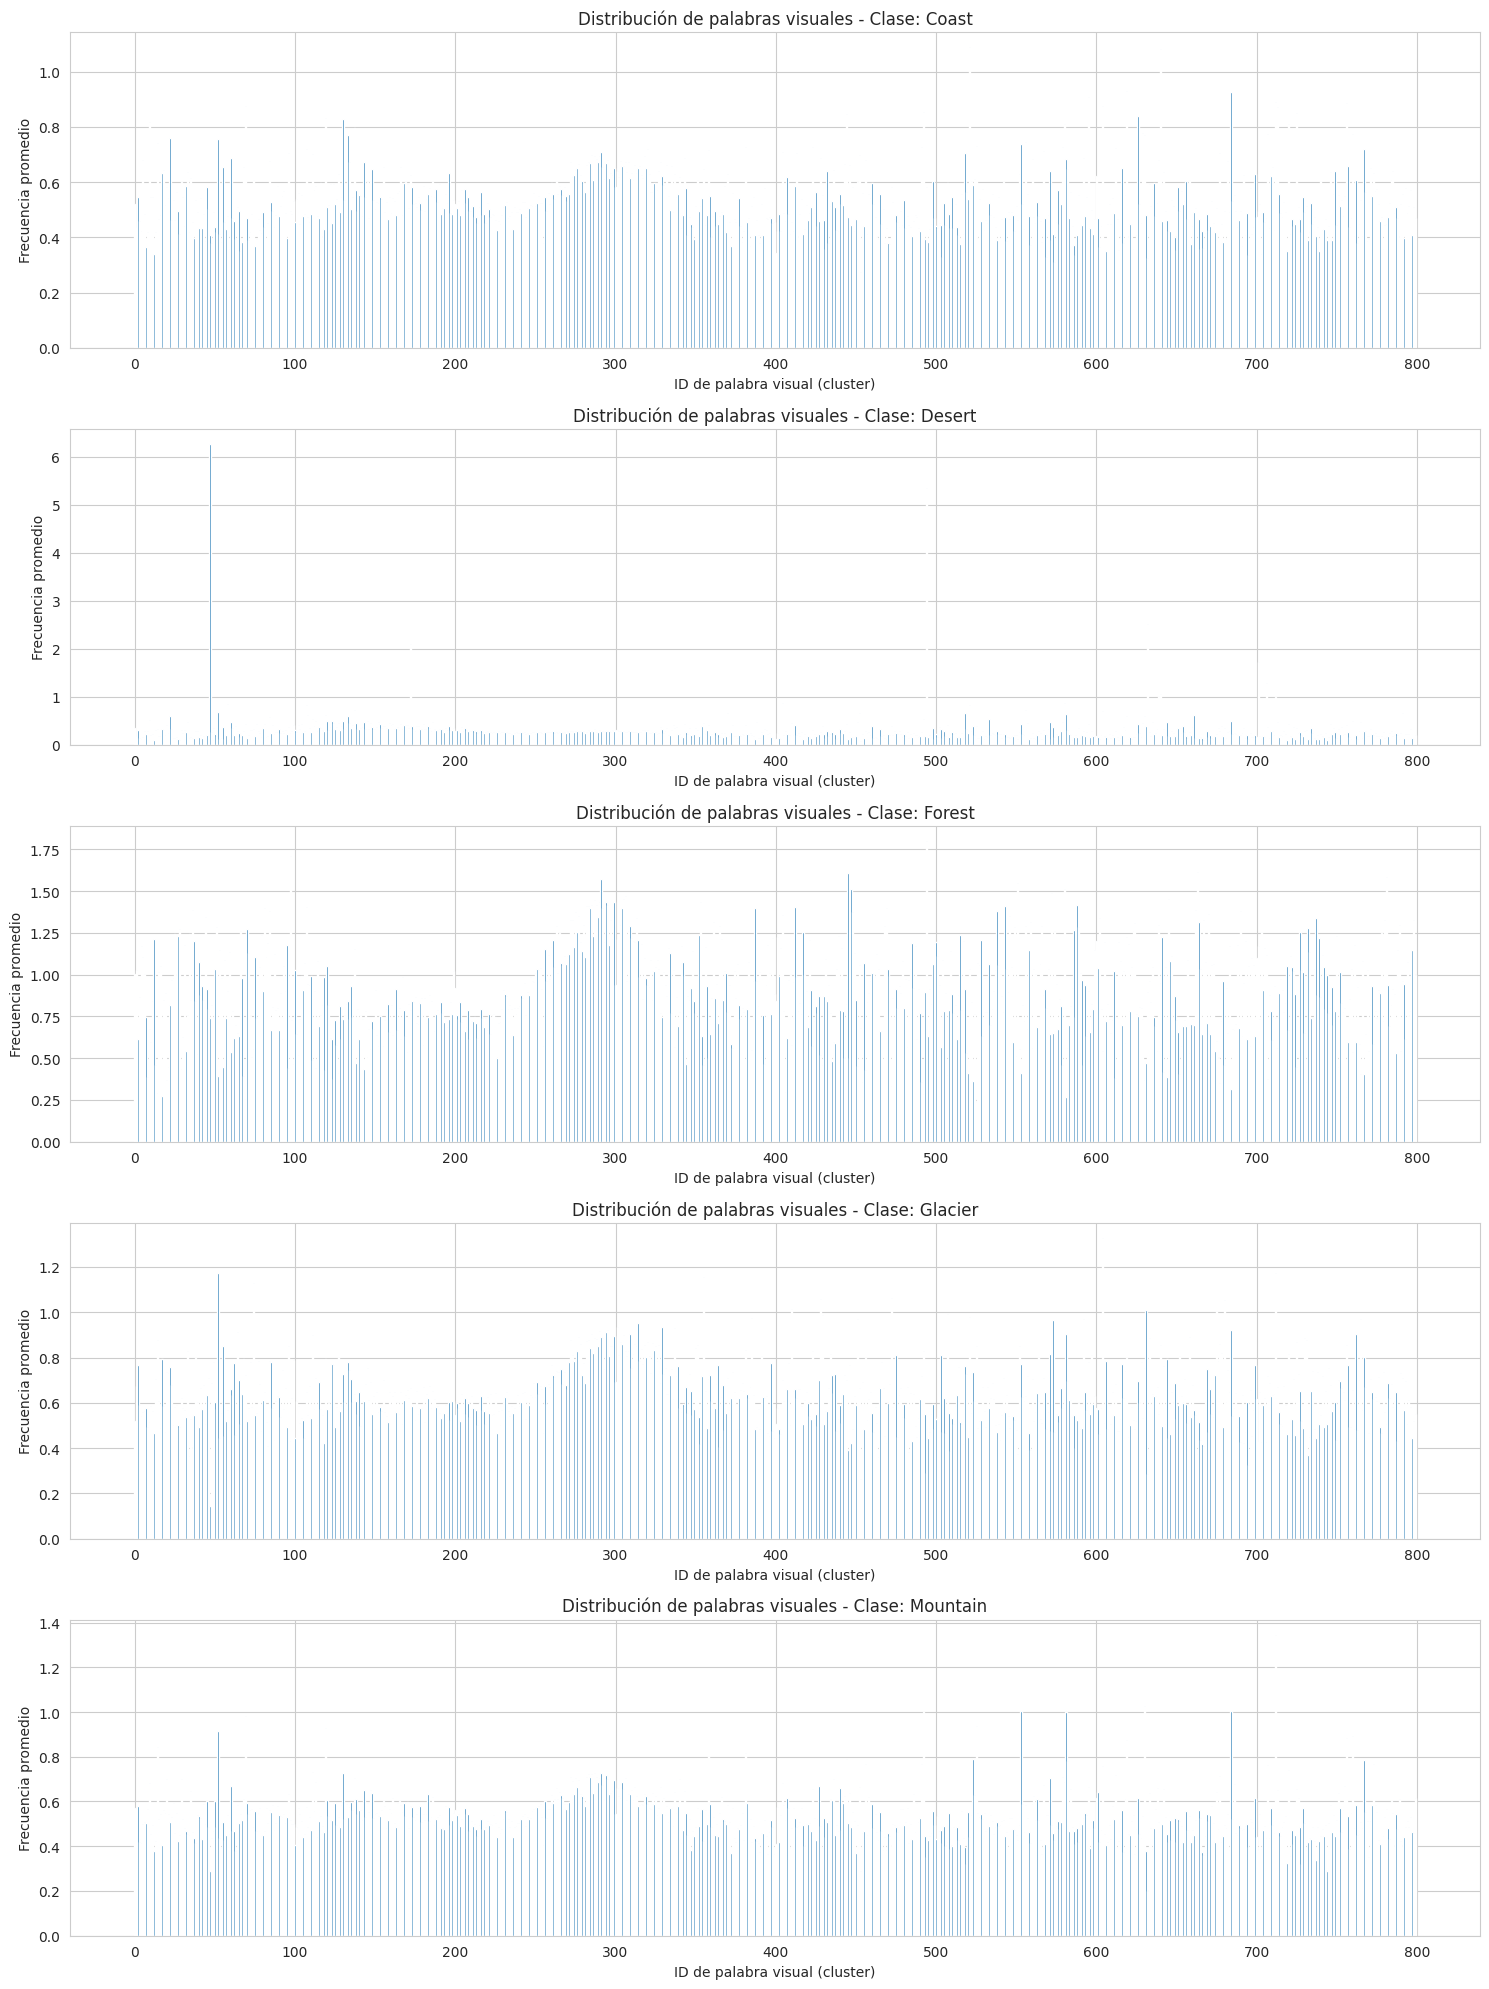

In [39]:
# Distribucion de palabras visuales por categoria

etiquetas = np.array(training_subset['etiquetas'])
representaciones = np.array(representaciones_tfidf)

clases_unicas = np.unique(etiquetas)

plt.figure(figsize=(15, 4 * len(clases_unicas)))
for i, clase in enumerate(clases_unicas):
    idx = np.where(etiquetas == clase)[0]
    hist_prom = np.mean(representaciones[idx], axis=0)

    plt.subplot(len(clases_unicas), 1, i + 1)
    plt.bar(np.arange(len(hist_prom)), hist_prom)
    plt.title(f"Distribución de palabras visuales - Clase: {clase}")
    plt.xlabel("ID de palabra visual (cluster)")
    plt.ylabel("Frecuencia promedio")
plt.tight_layout()
plt.show()

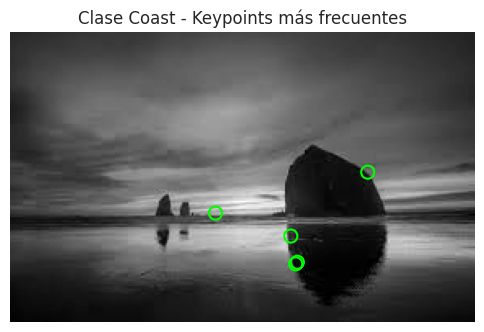

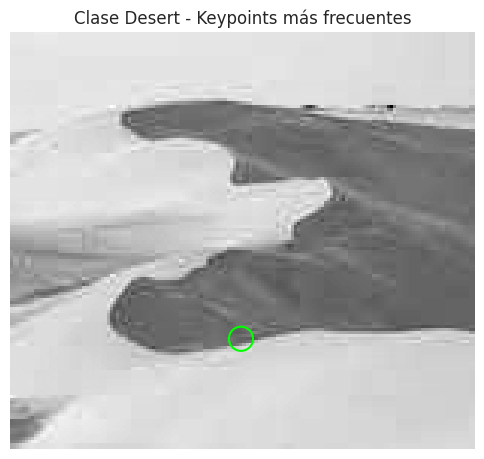

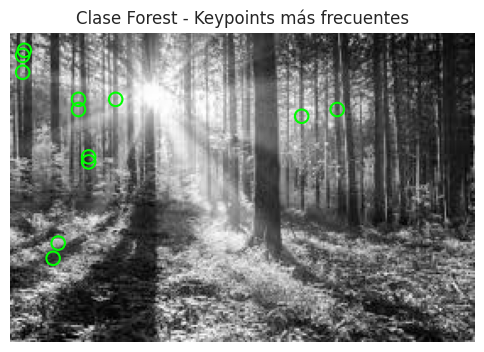

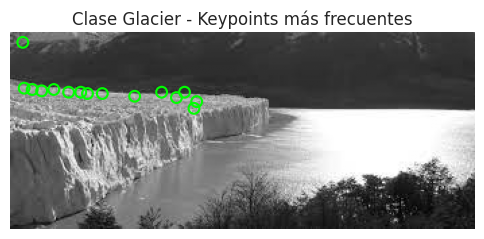

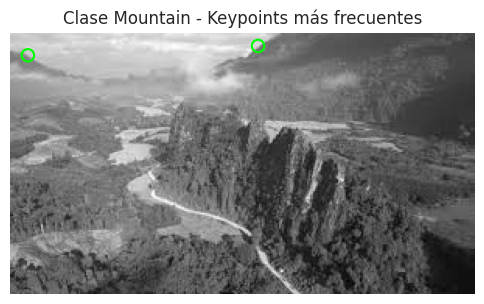

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import Counter
import random

# Paso 1: Agrupar palabras visuales por clase
clase_a_ids = {clase: [] for clase in np.unique(training_subset['etiquetas'])}

for des, label in zip(training_subset['descriptores'], training_subset['etiquetas']):
    if des is not None and len(des) > 0:
        ids = vocabulario.predict(des)
        clase_a_ids[label].extend(ids)

# Paso 2: Identificar palabras visuales más comunes por clase
clase_top_words = {
    clase: [wid for wid, _ in Counter(ids).most_common(5)]
    for clase, ids in clase_a_ids.items()
}

# Paso 3: Visualizar una imagen aleatoria por clase con keypoints destacados
for clase, palabras_comunes in clase_top_words.items():
    # Filtrar todas las imágenes de la clase actual
    indices_clase = [
        i for i, lbl in enumerate(training_subset['etiquetas'])
        if lbl == clase and training_subset['descriptores'][i] is not None and len(training_subset['descriptores'][i]) > 0
    ]

    if not indices_clase:
        continue  # No hay imágenes válidas para esta clase

    # Elegir un índice aleatorio
    idx = random.choice(indices_clase)

    img = training_subset['imagenes'][idx]
    des = training_subset['descriptores'][idx]
    kps = training_subset['keypoints'][idx]  # Nx2 array de (y, x)

    ids = vocabulario.predict(des)

    # Filtrar los keypoints cuya palabra visual esté entre las más comunes
    keypoints_filtrados = np.array(kps)[np.isin(ids, palabras_comunes)]

    # Dibujar
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img, cmap='gray')
    for (y, x) in keypoints_filtrados:
        circ = patches.Circle((x, y), radius=4, color='lime', fill=False, linewidth=1.5)
        ax.add_patch(circ)
    ax.set_title(f"Clase {clase} - Keypoints más frecuentes")
    ax.axis('off')
    plt.show()


Limitaciones Observadas + Propuestas de Mejora
- Idealmente, uno querria agregar informacion de color Y textura. Si solo pudieramos elegir uno, agregariamos informacion de color. Sift por si solo en escala de grises es incapaz de distinguir, a esta resolucion, entre arena y agua, que seria facil diferenciar por tener colores tan distintos agregando esta mejora.
- Por otro lado, hay muchas confusiones entre costa y otras clases, que al revisar el dataset, pareceria que podria estar causado porque las imagenes de costa que usamos para entrenar y validar suelen contener muchas features presentes en otras clases: suelen tener arboles (propio de bosque) y montañas (propio de montaña y glaciar). Seria conveniene curar el dataset y eliminar estos casos.

